# Problema 1 de Trabajo Práctico - Algoritmos de optimización <br>
Nombre y Apellidos: **Evelyn Sánchez**  <br>
Url: **https://github.com/eslaureano/Algoritmos_de_Optimizacion_MasterAI/tree/main/Trabajo_Practico** &nbsp; <br>

Problema:
> **Problema 1. Organizar sesiones de doblaje** <br>

**Descripción del problema:**

Se precisa coordinar el doblaje de una película. Los actores del doblaje deben coincidir en las tomas en las que sus personajes aparecen juntos en las diferentes tomas. Los actores de doblaje cobran todos la misma cantidad por cada día que deben desplazarse hasta el estudio de grabación, independientemente del número de tomas que se graben. No es posible grabar más de 6 tomas por día. El objetivo es planificar las sesiones por día de manera que el gasto por los servicios de los actores de doblaje sea el menor posible. Los datos son:

- **Número de actores:** 10
- **Número de tomas:** 30
- **Actores/Tomas:** matriz binaria de 30×10 — el elemento $(i,j)$ vale **1** si el actor $j$ participa en la toma $i$ y **0** en caso contrario.

Tomas: 30  |  Actores: 10
Capacidad por día: 6  ->  días mínimos: ceil(30/6) = 5
Participaciones por actor (tomas en las que aparece): [22 14 13 14 12  8  3  4  2  2]
Total de participaciones (unos de la matriz): 94


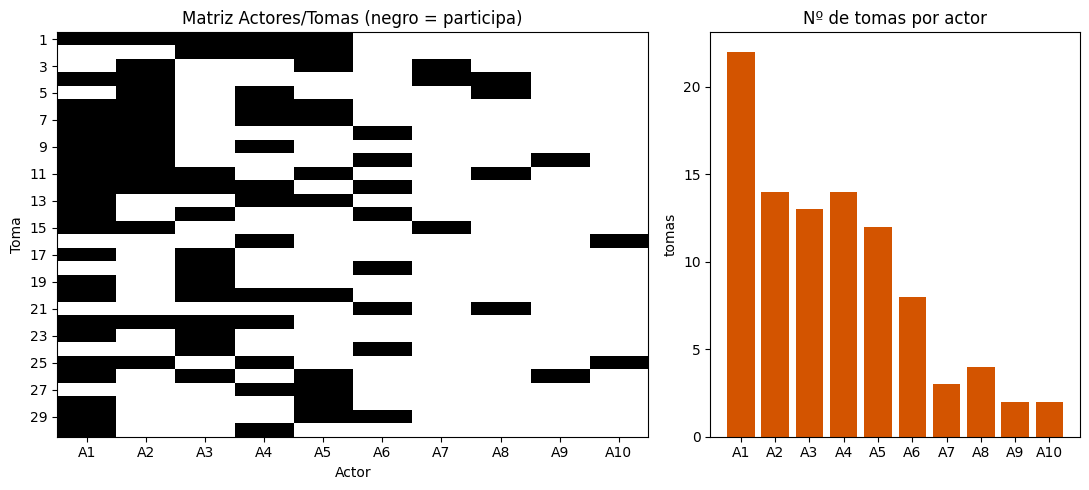

In [1]:
# =====================================================================
# CONFIGURACIÓN INICIAL Y CARGA DE DATOS DEL PROBLEMA
# =====================================================================
# Cada FILA de la matriz es una toma (1 a 30) y cada COLUMNA un actor (1 a 10).
#   1 -> el actor participa en la toma
#   0 -> no participa
#
# Matriz OFICIAL del problema, verificada celda a celda contra la hoja de
# cálculo del enunciado (https://bit.ly/36D8IuK):
# https://docs.google.com/spreadsheets/d/1Ipn6IrbQP4ax8zOnivdBIw2lN0JISkJG4fXndYd27U0
# Los totales por toma de la hoja coinciden con estas filas. (Nota: la fila
# "TOTAL" por actor de la hoja parece escrita a mano y difiere en los actores
# 4 y 5 de la suma real de sus columnas; se toman como válidos los datos de
# las celdas, que son autoconsistentes con los totales por toma.)

import math      # funciones matemáticas (ceil, log, exp, comb, factorial...)
import random    # generador de números aleatorios reproducible (semillas)
import time      # medición de tiempos de ejecución
import numpy as np
import matplotlib.pyplot as plt

DATOS_BRUTOS = """
1 1 1 1 1 0 0 0 0 0
0 0 1 1 1 0 0 0 0 0
0 1 0 0 1 0 1 0 0 0
1 1 0 0 0 0 1 1 0 0
0 1 0 1 0 0 0 1 0 0
1 1 0 1 1 0 0 0 0 0
1 1 0 1 1 0 0 0 0 0
1 1 0 0 0 1 0 0 0 0
1 1 0 1 0 0 0 0 0 0
1 1 0 0 0 1 0 0 1 0
1 1 1 0 1 0 0 1 0 0
1 1 1 1 0 1 0 0 0 0
1 0 0 1 1 0 0 0 0 0
1 0 1 0 0 1 0 0 0 0
1 1 0 0 0 0 1 0 0 0
0 0 0 1 0 0 0 0 0 1
1 0 1 0 0 0 0 0 0 0
0 0 1 0 0 1 0 0 0 0
1 0 1 0 0 0 0 0 0 0
1 0 1 1 1 0 0 0 0 0
0 0 0 0 0 1 0 1 0 0
1 1 1 1 0 0 0 0 0 0
1 0 1 0 0 0 0 0 0 0
0 0 1 0 0 1 0 0 0 0
1 1 0 1 0 0 0 0 0 1
1 0 1 0 1 0 0 0 1 0
0 0 0 1 1 0 0 0 0 0
1 0 0 0 1 0 0 0 0 0
1 0 0 0 1 1 0 0 0 0
1 0 0 1 0 0 0 0 0 0
"""

# Convertimos el texto en una matriz numpy de enteros (30 x 10)
MATRIZ = np.array([[int(x) for x in fila.split()]
                   for fila in DATOS_BRUTOS.strip().splitlines()], dtype=int)

N_TOMAS, N_ACTORES = MATRIZ.shape
CAPACIDAD = 6                              # restricción: máximo de tomas por día
N_DIAS = math.ceil(N_TOMAS / CAPACIDAD)    # número mínimo de días necesarios (=5)

print(f"Tomas: {N_TOMAS}  |  Actores: {N_ACTORES}")
print(f"Capacidad por día: {CAPACIDAD}  ->  días mínimos: ceil({N_TOMAS}/{CAPACIDAD}) = {N_DIAS}")
print(f"Participaciones por actor (tomas en las que aparece): {MATRIZ.sum(axis=0)}")
print(f"Total de participaciones (unos de la matriz): {MATRIZ.sum()}")

# --- Ilustración de los datos -----------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(11, 5), gridspec_kw={"width_ratios": [1.6, 1]})

# Mapa de calor de la matriz Actores/Tomas
ax[0].imshow(MATRIZ, cmap="Greys", aspect="auto")
ax[0].set_xticks(range(N_ACTORES))
ax[0].set_xticklabels([f"A{j+1}" for j in range(N_ACTORES)])
ax[0].set_yticks(range(0, N_TOMAS, 2))
ax[0].set_yticklabels(range(1, N_TOMAS + 1, 2))
ax[0].set_xlabel("Actor"); ax[0].set_ylabel("Toma")
ax[0].set_title("Matriz Actores/Tomas (negro = participa)")

# Número de tomas por actor: se aprecia que A1 y A2 son protagonistas
ax[1].bar([f"A{j+1}" for j in range(N_ACTORES)], MATRIZ.sum(axis=0), color="#d35400")
ax[1].set_title("Nº de tomas por actor")
ax[1].set_ylabel("tomas")
plt.tight_layout(); plt.show()

---

> # **Preguntas y respuestas** <br>

---



**(1)¿Cuantas posibilidades hay sin tener en cuenta las restricciones?**<br>



**(2)¿Cuantas posibilidades hay teniendo en cuenta todas las restricciones?**

#### Respuesta

**Idea clave.** Planificar las sesiones consiste en **repartir el conjunto de las 30 tomas en grupos (días de grabación)**. Lo único relevante para el coste es *qué tomas se graban juntas*: los días no tienen identidad propia (la misma agrupación, grabada en otro orden de días, cuesta lo mismo). Por tanto, **cada solución es una partición del conjunto de tomas**.

**1) Sin tener en cuenta las restricciones** (sin límite de tomas por día):

El número de particiones de un conjunto de $n$ elementos es el **número de Bell** $B_n$, que se calcula con la recurrencia
$$B_{n+1}=\sum_{k=0}^{n}\binom{n}{k}B_k, \qquad B_0=1$$
Para $n=30$ tomas el valor exacto se calcula en la celda siguiente: $B_{30}\approx 8{,}47\cdot 10^{23}$ posibilidades.
*(Si además se etiquetaran los días —"día 1", "día 2", ...— el número sería todavía mayor; usamos la versión sin etiquetas porque describe las soluciones realmente distintas.)*

**2) Teniendo en cuenta todas las restricciones** (máximo 6 tomas por día):

Hay que contar únicamente las particiones cuyos bloques tienen **tamaño ≤ 6**. Fijando el tamaño $k$ del bloque que contiene a un elemento concreto se obtiene la recurrencia
$$a(n)=\sum_{k=1}^{6}\binom{n-1}{k-1}\,a(n-k), \qquad a(0)=1$$
que se evalúa de forma exacta en la celda siguiente ($a(30)=B_{\le 6}(30)$).

Como caso particular relevante: el **mínimo número de días** es $\lceil 30/6\rceil = 5$, y con 5 días todos deben estar completos (6 tomas cada uno). El número de planificaciones de ese tipo es
$$\frac{30!}{(6!)^5\cdot 5!}\approx 1{,}14\cdot 10^{16}$$

**Conclusión:** el espacio de soluciones es astronómico en los tres recuentos, lo que descarta la exploración exhaustiva y justifica el uso de heurísticas.
*(Estos números son **combinatoria** —el tamaño del espacio de soluciones—; **no** son la complejidad de ningún algoritmo, que se analiza más adelante.)*


a) SIN restricciones  (particiones de 30 tomas):
   B(30) = 846,749,014,511,809,332,450,147  ≈ 8.467e+23

b) CON restricciones  (particiones con bloques <= 6 tomas):
   B_<=6(30) = 726,391,948,970,868,949,621,309  ≈ 7.264e+23

   Caso particular, 5 días completos de 6 tomas:
   30!/((6!)^5·5!) = 11,423,951,396,577,720  ≈ 1.142e+16



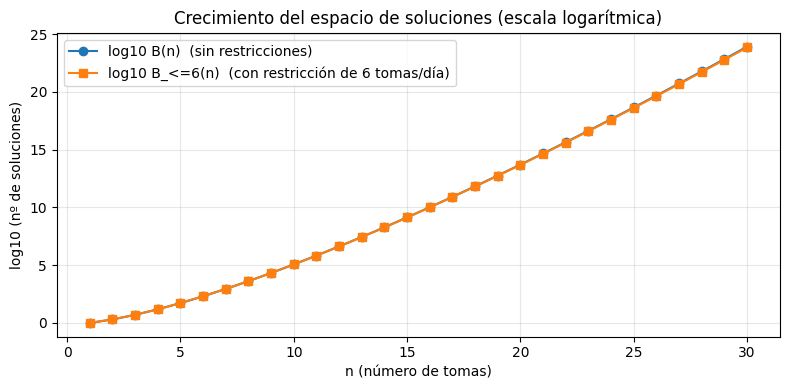

In [4]:
# =====================================================================
# CÁLCULO EXACTO DE LA COMBINATORIA (con enteros de precisión arbitraria)
# =====================================================================
from math import comb, factorial

def numero_bell(n):
    """Número de Bell B(n): particiones de un conjunto de n elementos.
    Se calcula con la recurrencia B(m+1) = sum_k C(m,k)·B(k)."""
    B = [1]                                  # B(0) = 1
    for m in range(n):
        B.append(sum(comb(m, k) * B[k] for k in range(m + 1)))
    return B[n]

def particiones_bloques_max(n, cap):
    """Nº de particiones de un conjunto de n elementos con TODOS los bloques
    de tamaño <= cap.  Recurrencia (fijando el bloque de un elemento dado):
        a(n) = sum_{k=1..cap} C(n-1, k-1) · a(n-k),   a(0) = 1
    """
    a = [1] + [0] * n
    for m in range(1, n + 1):
        a[m] = sum(comb(m - 1, k - 1) * a[m - k]
                   for k in range(1, min(cap, m) + 1))
    return a[n]

# --- Comprobaciones de sanidad (valores conocidos) --------------------
assert numero_bell(5) == 52
assert particiones_bloques_max(4, 4) == numero_bell(4)   # sin restricción efectiva

# --- 1) Sin restricciones: B(30) --------------------------------------
sin_restr = numero_bell(N_TOMAS)
print("a) SIN restricciones  (particiones de 30 tomas):")
print(f"   B(30) = {sin_restr:,}  ≈ {float(sin_restr):.3e}\n")

# --- 2) Con restricciones: bloques de tamaño <= 6 ---------------------
con_restr = particiones_bloques_max(N_TOMAS, CAPACIDAD)
print("b) CON restricciones  (particiones con bloques <= 6 tomas):")
print(f"   B_<=6(30) = {con_restr:,}  ≈ {float(con_restr):.3e}\n")

# --- Caso particular: exactamente 5 días completos de 6 tomas ---------
cinco_dias = factorial(30) // (factorial(6) ** 5 * factorial(5))
print("   Caso particular, 5 días completos de 6 tomas:")
print(f"   30!/((6!)^5·5!) = {cinco_dias:,}  ≈ {float(cinco_dias):.3e}\n")

# --- Ilustración: crecimiento del espacio de soluciones ---------------
ns = range(1, 31)
plt.figure(figsize=(8, 4))
plt.plot(ns, [math.log10(numero_bell(n)) for n in ns], "o-",
         label="log10 B(n)  (sin restricciones)")
plt.plot(ns, [math.log10(particiones_bloques_max(n, CAPACIDAD)) for n in ns], "s-",
         label="log10 B_<=6(n)  (con restricción de 6 tomas/día)")
plt.xlabel("n (número de tomas)")
plt.ylabel("log10 (nº de soluciones)")
plt.title("Crecimiento del espacio de soluciones (escala logarítmica)")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

Modelo para el espacio de soluciones<br>
**(3) ¿Cual es la estructura de datos que mejor se adapta al problema? Argumenta la respuesta.**

#### Respuesta

**Para los datos** la elección es directa: una **matriz binaria** `numpy` de tamaño *tomas × actores*. Es la representación natural del enunciado y permite consultas vectorizadas (participaciones por actor, actores por toma, uniones por día...).

**Para las soluciones** hubo una **evolución razonada**:

1. **Primera idea — lista de listas** (`dias = [[tomas del día 1], [tomas del día 2], ...]`). Es la representación más legible, pero al implementar los algoritmos aparecen dos problemas: (i) los operadores de vecindad deben vigilar constantemente la restricción de capacidad, y (ii) evaluar el coste obliga a recorrer estructuras anidadas de tamaño variable.

2. **Cambio 1 — solución como permutación.** Como $30 = 5\times 6$, **toda** partición factible en 5 días tiene exactamente 6 tomas por día. Por ello codificamos la solución como una **permutación de las 30 tomas** que se trocea en 5 bloques consecutivos de 6: las posiciones 0–5 son el día 1, las 6–11 el día 2, etc.
   - La **factibilidad queda garantizada por construcción** (nunca se supera la capacidad): no hay que comprobar restricciones.
   - El **operador de vecindad** es el intercambio de dos posiciones, exactamente el operador visto en las diapositivas para permutaciones (TSP, "Opción 2: se eligen dos elementos y se intercambian").
   - La codificación no deja fuera ninguna partición factible de 5 días (cada partición aparece representada por varias permutaciones, pero todas aparecen).

3. **Cambio 2 — máscaras de bits para evaluar rápido.** Cada toma se codifica además como un **entero de 10 bits** (bit $j$ = participa el actor $j$). Así, el conjunto de actores de un día es un **OR** de 6 enteros y "contar actores distintos" es contar los bits a 1 (*popcount*). La evaluación de un día pasa de recorrer submatrices a **6 operaciones de bits**, lo que resulta crítico porque la metaheurística evalúa cientos de miles de vecinos.

**Estructura final:** matriz `numpy` (datos) + **permutación troceada en días** (solución) + **máscaras de bits** (evaluación). La matriz se conserva para visualización y verificación cruzada de la función objetivo.


In [5]:
# =====================================================================
# ESTRUCTURAS DE DATOS DEL MODELO
# =====================================================================

def construir_mascaras(matriz):
    """Codifica cada toma como un entero: el bit j vale 1 si el actor j
    participa en la toma.  Ej.: la toma con actores {1,2,5} -> 0b0000010011."""
    return [int(sum(int(fila[j]) << j for j in range(len(fila))))
            for fila in matriz]

def contar_bits(x):
    """Popcount: nº de bits a 1 (nº de actores distintos de una máscara)."""
    return bin(x).count("1")

def tamanos_dias(n_tomas, capacidad):
    """Tamaños equilibrados de los días respetando la capacidad.
    Con 30 tomas y capacidad 6 -> [6, 6, 6, 6, 6]."""
    n_dias = math.ceil(n_tomas / capacidad)
    base, resto = divmod(n_tomas, n_dias)
    return [base + 1 if d < resto else base for d in range(n_dias)]

def limites(tamanos):
    """Convierte los tamaños de los días en índices [inicio, fin) sobre la
    permutación.  [6,6,6,6,6] -> [(0,6), (6,12), (12,18), (18,24), (24,30)]."""
    lim, ini = [], 0
    for t in tamanos:
        lim.append((ini, ini + t))
        ini += t
    return lim

def dia_de_cada_posicion(limites_dias):
    """Vector auxiliar: día al que pertenece cada posición de la permutación."""
    return [d for d, (i, j) in enumerate(limites_dias) for _ in range(j - i)]

def decodificar(perm, limites_dias):
    """Permutación -> lista de días (cada día = lista de tomas)."""
    return [list(perm[i:j]) for (i, j) in limites_dias]

# --- Estructuras para la instancia real -------------------------------
MASCARAS   = construir_mascaras(MATRIZ)
TAMANOS    = tamanos_dias(N_TOMAS, CAPACIDAD)     # [6, 6, 6, 6, 6]
LIMITES    = limites(TAMANOS)
DIA_DE_POS = dia_de_cada_posicion(LIMITES)

print("Tamaños de los días:", TAMANOS)
print("Límites de cada día en la permutación:", LIMITES)
print()
print("Ejemplo de máscara — toma 1 con actores {1,2,3,4,5}:")
print(f"  bits = {format(MASCARAS[0], '010b')} (leídos de derecha a izquierda)"
      f"  ->  {contar_bits(MASCARAS[0])} actores")
print()
print("Ejemplo de decodificación (permutación en orden natural):")
for d, tomas in enumerate(decodificar(list(range(N_TOMAS)), LIMITES), 1):
    print(f"  Día {d}: tomas {[t + 1 for t in tomas]}")

Tamaños de los días: [6, 6, 6, 6, 6]
Límites de cada día en la permutación: [(0, 6), (6, 12), (12, 18), (18, 24), (24, 30)]

Ejemplo de máscara — toma 1 con actores {1,2,3,4,5}:
  bits = 0000011111 (leídos de derecha a izquierda)  ->  5 actores

Ejemplo de decodificación (permutación en orden natural):
  Día 1: tomas [1, 2, 3, 4, 5, 6]
  Día 2: tomas [7, 8, 9, 10, 11, 12]
  Día 3: tomas [13, 14, 15, 16, 17, 18]
  Día 4: tomas [19, 20, 21, 22, 23, 24]
  Día 5: tomas [25, 26, 27, 28, 29, 30]


Según el modelo para el espacio de soluciones<br>
**(4)¿Cual es la función objetivo?**

**(5)¿Es un problema de maximización o minimización?**


#### Respuesta

**Función objetivo.** Cada actor cobra una jornada por cada día en el que grabe **al menos una** toma. Si $A_t$ es el conjunto de actores de la toma $t$ y $S$ divide las tomas en los días $D_1,\dots,D_5$, el gasto total (en jornadas de actor) es:

$$C(S)\;=\;\sum_{d=1}^{5}\;\Bigl|\,\bigcup_{t\in D_d} A_t\Bigr|$$

es decir, la **suma, sobre los días, del número de actores distintos convocados cada día**. (Como todos cobran lo mismo, minimizar el gasto en € equivale a minimizar el número total de jornadas.)

**Tipo de problema: MINIMIZACIÓN** — se busca la planificación $S^*$ con $C(S^*)$ mínimo.

**Cota inferior (referencia de calidad sin usar solvers).** El actor $i$ participa en $t_i$ tomas; como cada día se graban a lo sumo 6, sus tomas ocupan al menos $\lceil t_i/6\rceil$ días distintos y por tanto cobra al menos esas jornadas. Sumando sobre los actores:

$$C(S)\;\ge\;\sum_{i=1}^{10}\Bigl\lceil \tfrac{t_i}{6} \Bigr\rceil \qquad \text{para toda solución } S$$

Esta cota nos permite acotar *cuán lejos puede estar como máximo* nuestra solución del óptimo, que es el papel que el enunciado reserva a un solver de referencia.


In [6]:
# =====================================================================
# FUNCIÓN OBJETIVO (dos implementaciones + verificación cruzada) Y COTA
# =====================================================================

def coste_dia(tomas_dia, mascaras):
    """Nº de actores distintos que trabajan un día:
    OR de las máscaras de sus tomas + popcount."""
    m = 0
    for t in tomas_dia:
        m |= mascaras[t]
    return contar_bits(m)

def coste_perm(perm, mascaras, limites_dias):
    """FUNCIÓN OBJETIVO C(S): suma de actores distintos por día (versión
    rápida con máscaras de bits; se usa dentro de los algoritmos)."""
    return sum(coste_dia(perm[i:j], mascaras) for (i, j) in limites_dias)

def coste(perm):
    """Atajo de la función objetivo para la instancia real del enunciado."""
    return coste_perm(perm, MASCARAS, LIMITES)

def coste_numpy(perm, matriz, limites_dias):
    """Misma función objetivo implementada con numpy (más legible, más
    lenta). Sirve para VERIFICAR que la versión con máscaras es correcta."""
    return int(sum(matriz[list(perm[i:j])].any(axis=0).sum()
                   for (i, j) in limites_dias))

# --- Verificación cruzada sobre 200 soluciones aleatorias -------------
rng_test = random.Random(0)
for _ in range(200):
    p = list(range(N_TOMAS))
    rng_test.shuffle(p)
    assert coste(p) == coste_numpy(p, MATRIZ, LIMITES), "¡las dos versiones difieren!"
print("Verificación de la función objetivo: las 2 implementaciones coinciden ✔")

sol_trivial = list(range(N_TOMAS))   # días en orden natural: 1-6, 7-12, ...
print(f"Coste de la solución trivial (orden natural): {coste(sol_trivial)} jornadas")

# --- Cota inferior combinatoria ---------------------------------------
def cota_inferior(matriz, capacidad):
    """C* >= sum_i ceil(t_i / capacidad), con t_i = nº de tomas del actor i."""
    return int(sum(math.ceil(t / capacidad) for t in matriz.sum(axis=0)))

COTA = cota_inferior(MATRIZ, CAPACIDAD)
print(f"Cota inferior del óptimo: C* >= {COTA} jornadas "
      f"(detalle por actor: {[math.ceil(t / CAPACIDAD) for t in MATRIZ.sum(axis=0)]})")

Verificación de la función objetivo: las 2 implementaciones coinciden ✔
Coste de la solución trivial (orden natural): 38 jornadas
Cota inferior del óptimo: C* >= 21 jornadas (detalle por actor: [4, 3, 3, 3, 2, 2, 1, 1, 1, 1])


**(6)Diseña un algoritmo para resolver el problema por fuerza bruta**

#### Respuesta

**Diseño: enumeración exhaustiva de particiones sin repeticiones.**

Se recorren las tomas en orden $0,1,\dots,n-1$. La toma $i$ puede:
- **(a)** unirse a cualquier día ya abierto que tenga hueco (menos de 6 tomas), o
- **(b)** abrir un día nuevo.

Esta construcción recursiva genera **cada partición exactamente una vez** (*forma canónica*): al no etiquetar los días se elimina la simetría de "reordenar los días", que multiplicaría el trabajo por hasta $5! = 120$ sin aportar soluciones nuevas. En cada hoja (todas las tomas asignadas) se evalúa la función objetivo y se conserva la mejor solución encontrada. El coste por día se mantiene **incrementalmente** con las máscaras de bits.

**Pseudocódigo**
```
FUERZA_BRUTA(i):
    si i == n:
        evaluar la partición actual; actualizar la mejor; volver
    para cada día abierto b con hueco (|b| < 6):
        añadir la toma i a b ; FUERZA_BRUTA(i+1) ; deshacer
    abrir un día nuevo con la toma i ; FUERZA_BRUTA(i+1) ; deshacer
```

El algoritmo **garantiza el óptimo**, pero es inviable para $n=30$ (ver el análisis de complejidad). Se demuestra sobre una **instancia reducida con las 10 primeras tomas**, donde sí obtiene el óptimo exacto — que después usaremos para **validar la heurística**.


In [7]:
# =====================================================================
# ALGORITMO POR FUERZA BRUTA (enumeración exhaustiva de particiones)
# =====================================================================

def fuerza_bruta(mascaras, capacidad):
    """Explora TODAS las particiones del conjunto de tomas en días de
    tamaño <= capacidad (cada partición se genera exactamente una vez).
    Devuelve (mejor_coste, mejor_particion, particiones_evaluadas)."""
    n = len(mascaras)
    bloques = []          # partición en construcción: lista de días (listas de tomas)
    masc_bloques = []     # máscara de actores acumulada de cada día (incremental)
    mejor = {"coste": float("inf"), "particion": None}
    contador = [0]        # nº de particiones completas evaluadas

    def rec(i):
        if i == n:                                   # ---- hoja: partición completa
            contador[0] += 1
            c = sum(contar_bits(m) for m in masc_bloques)   # evaluar C(S)
            if c < mejor["coste"]:                   # ¿mejora la mejor conocida?
                mejor["coste"] = c
                mejor["particion"] = [list(b) for b in bloques]
            return
        # (a) añadir la toma i a cada día ya abierto que tenga hueco
        for b in range(len(bloques)):
            if len(bloques[b]) < capacidad:
                bloques[b].append(i)
                antigua = masc_bloques[b]
                masc_bloques[b] = antigua | mascaras[i]      # actualización O(1)
                rec(i + 1)
                bloques[b].pop()                             # deshacer (backtracking)
                masc_bloques[b] = antigua
        # (b) abrir un día nuevo con la toma i
        bloques.append([i])
        masc_bloques.append(mascaras[i])
        rec(i + 1)
        bloques.pop()
        masc_bloques.pop()

    rec(0)
    return mejor["coste"], mejor["particion"], contador[0]

# --- Demostración sobre una instancia reducida (10 primeras tomas) ----
N_RED = 10
t0 = time.perf_counter()
COSTE_OPT_RED, PART_OPT_RED, N_PART_RED = fuerza_bruta(MASCARAS[:N_RED], CAPACIDAD)
T_FB_RED = time.perf_counter() - t0

print(f"Instancia reducida: {N_RED} primeras tomas, capacidad {CAPACIDAD}")
print(f"  Particiones evaluadas : {N_PART_RED:,}")
print(f"  Fórmula B_<=6({N_RED})    : {particiones_bloques_max(N_RED, CAPACIDAD):,} "
      f"{'✔ coincide' if N_PART_RED == particiones_bloques_max(N_RED, CAPACIDAD) else '✘'}")
print(f"  Tiempo                : {T_FB_RED:.2f} s")
print(f"  ÓPTIMO EXACTO         : {COSTE_OPT_RED} jornadas, con la partición:")
for d, b in enumerate(PART_OPT_RED, 1):
    actores = sorted(int(a) for a in np.where(MATRIZ[b].any(axis=0))[0] + 1)
    print(f"    Día {d}: tomas {[t + 1 for t in b]}  ->  actores {actores}")

Instancia reducida: 10 primeras tomas, capacidad 6
  Particiones evaluadas : 115,274
  Fórmula B_<=6(10)    : 115,274 ✔ coincide
  Tiempo                : 0.28 s
  ÓPTIMO EXACTO         : 13 jornadas, con la partición:
    Día 1: tomas [1, 2, 3, 4, 5, 6]  ->  actores [1, 2, 3, 4, 5, 7, 8]
    Día 2: tomas [7, 8, 9, 10]  ->  actores [1, 2, 4, 5, 6, 9]


**(7)Calcula la complejidad del algoritmo por fuerza bruta**

#### Respuesta

Sea $n$ el número de tomas, $a$ el de actores y $c=6$ la capacidad.

- El árbol de búsqueda tiene **una hoja por cada partición factible**, es decir, $B_{\le c}(n)$ hojas (lo hemos comprobado empíricamente: el contador del algoritmo coincide exactamente con la fórmula de la sección de combinatoria).
- El trabajo en cada hoja es la evaluación de la función objetivo: $O(n)$ en el peor caso (con el mantenimiento incremental de máscaras queda en $O(D)$ *popcounts*, $D \le n$). El trabajo de los nodos internos es del mismo orden que el número de hojas (cada nodo interno realiza $O(c)$ trabajo por rama).

$$\boxed{\;T(n)\in O\bigl(n\cdot B_{\le 6}(n)\bigr)\;}\qquad\text{Espacio: } O(n)\ \text{(partición en curso + pila de recursión)}$$

Como $B_{\le 6}(n)$ crece de forma **superexponencial**, el algoritmo es inviable en cuanto $n$ crece un poco: garantiza el óptimo, pero a un coste temporal explosivo.

> **Combinatoria vs. complejidad (de nuevo):** $B_{\le 6}(n)$ es el *número de soluciones* (combinatoria); $n\cdot B_{\le 6}(n)$ es el *número de operaciones que ejecuta este algoritmo* (complejidad). Coinciden en orden de magnitud precisamente **porque** la fuerza bruta visita todas las soluciones — la heurística romperá ese vínculo.

La celda siguiente **extrapola** el tiempo medido en $n=10$ al resto de tamaños: para $n=30$ harían falta ~$10^{12}$ años de cómputo.


Tiempo medido por partición: 2.40 microsegundos

   n |     B_<=6(n) (particiones) |        tiempo estimado
------------------------------------------------------------
  10 |                    115,274 |                 0.28 s
  14 |                187,160,429 |             0.12 horas
  18 |            654,277,037,674 |              18.2 días
  22 |      4,196,351,007,814,659 |               320 años
  26 | 44,519,299,362,653,156,562 |          3.39e+06 años
  30 | 726,391,948,970,868,949,621,309 |          5.53e+10 años


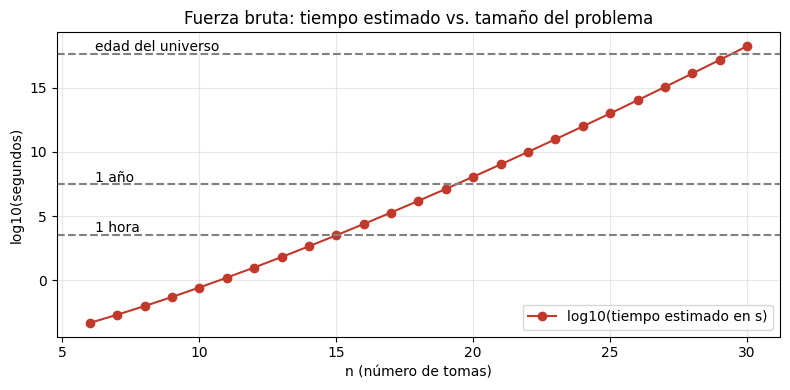

In [8]:
# =====================================================================
# EXTRAPOLACIÓN DEL TIEMPO DE LA FUERZA BRUTA (medido en n = 10)
# =====================================================================
t_por_particion = T_FB_RED / N_PART_RED       # segundos por partición (medido)
SEG_ANO = 365.25 * 24 * 3600
print(f"Tiempo medido por partición: {t_por_particion*1e6:.2f} microsegundos\n")
print(f"{'n':>4} | {'B_<=6(n) (particiones)':>26} | {'tiempo estimado':>22}")
print("-" * 60)
for n in [10, 14, 18, 22, 26, 30]:
    npart = particiones_bloques_max(n, CAPACIDAD)
    seg = t_por_particion * npart
    if seg < 60:            eti = f"{seg:.2f} s"
    elif seg < 86400:       eti = f"{seg/3600:.2f} horas"
    elif seg < SEG_ANO:     eti = f"{seg/86400:.1f} días"
    else:                   eti = f"{seg/SEG_ANO:.3g} años"
    print(f"{n:>4} | {npart:>26,} | {eti:>22}")

# --- Ilustración -------------------------------------------------------
ns = range(6, 31)
est = [math.log10(t_por_particion * particiones_bloques_max(n, CAPACIDAD)) for n in ns]
plt.figure(figsize=(8, 4))
plt.plot(ns, est, "o-", color="#c0392b", label="log10(tiempo estimado en s)")
plt.axhline(math.log10(3600),   ls="--", c="gray");  plt.text(6.2, math.log10(3600)+.2, "1 hora")
plt.axhline(math.log10(SEG_ANO), ls="--", c="gray"); plt.text(6.2, math.log10(SEG_ANO)+.2, "1 año")
plt.axhline(math.log10(4.35e17), ls="--", c="gray"); plt.text(6.2, math.log10(4.35e17)+.2, "edad del universo")
plt.xlabel("n (número de tomas)"); plt.ylabel("log10(segundos)")
plt.title("Fuerza bruta: tiempo estimado vs. tamaño del problema")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

**(8)Diseña un algoritmo que mejore la complejidad del algortimo por fuerza bruta. Argumenta porque crees que mejora el algoritmo por fuerza bruta**

#### Respuesta

Se diseña una estrategia **heurística en tres capas**, con las técnicas de la sesión VC5:

1. **Constructivo voraz aleatorizado** (idea GRASP, diapositivas §7): construye los días uno a uno; abre cada día con una toma pendiente al azar (*componente aleatoria*) y lo completa añadiendo en cada paso la toma que **menos actores nuevos** incorpora al día (*criterio voraz*, evaluado de forma *adaptativa* sobre el estado del día). Produce soluciones iniciales de buena calidad en tiempo polinómico.

2. **Búsqueda local con multiarranque** (diapositivas §3 y §6): a partir de una solución, examina vecinos generados con el **operador de intercambio** de dos tomas de días distintos y acepta la primera mejora; al estancarse (óptimo local), reinicia desde otra solución aleatoria. Sirve además como método de comparación.

3. **Recocido simulado — algoritmo principal** (diapositivas §5; Kirkpatrick et al., 1983): mismo operador de vecindad, pero acepta también empeoramientos con probabilidad $P_{aceptación}= e^{-\delta/T}$, donde $\delta = C(s') - C(s)$ y $T$ desciende con **enfriamiento exponencial** $T_{k+1}=\alpha\, T_k$. La temperatura inicial se **calibra automáticamente** muestreando deltas de vecinos para aceptar ~80 % de los empeoramientos al inicio: *diversificación al principio, intensificación al final*. Criterio de parada: número de iteraciones.

Pieza clave de eficiencia: la **evaluación incremental** — un intercambio solo afecta a 2 días, así que $\delta$ se calcula reevaluando únicamente esos 2 días ($O(c)$ operaciones de bits) en lugar de toda la solución.

**¿Por qué mejora a la fuerza bruta?**
- La fuerza bruta ejecuta $O(n\cdot B_{\le 6}(n))$ operaciones porque **visita todas** las soluciones. La heurística visita solo $I$ soluciones (presupuesto fijado por el usuario) con coste **constante por iteración**: su tiempo deja de depender del tamaño del espacio de soluciones.
- Está **guiada**: el voraz parte de una zona buena, la búsqueda local intensifica y el recocido aporta el mecanismo de **escape de óptimos locales** que a la búsqueda local pura le falta (diapositivas: "permitir movimientos peores").
- **Contrapartida** (inconvenientes de las metaheurísticas, diapositivas §1): es un método aproximado y no determinista — no garantiza el óptimo. Por eso se valida: (i) contra el **óptimo exacto** de la fuerza bruta en la instancia reducida y (ii) contra la **cota inferior** en la instancia completa.


In [9]:
# =====================================================================
# ALGORITMO MEJORADO — IMPLEMENTACIÓN
#   1) constructivo voraz aleatorizado (tipo GRASP)
#   2) búsqueda local (intercambio) + multiarranque
#   3) recocido simulado (algoritmo principal)
# Todas las funciones son genéricas: reciben las máscaras y la estructura
# de días, de modo que sirven igual para la instancia real, la reducida
# y el juego de datos aleatorio.
# =====================================================================
SEMILLA = 2026   # semilla global -> resultados reproducibles

# ---------------------------------------------------------------------
# Soluciones iniciales
# ---------------------------------------------------------------------
def solucion_aleatoria(n_tomas, rng):
    """Permutación aleatoria uniforme de las tomas."""
    perm = list(range(n_tomas))
    rng.shuffle(perm)
    return perm

def solucion_voraz(mascaras, tamanos, rng):
    """Constructivo voraz aleatorizado (idea GRASP):
    - abre cada día con una toma pendiente elegida al azar;
    - mientras quede hueco, añade la toma pendiente que MENOS actores
      nuevos aporta al día (criterio voraz adaptativo).
    """
    pendientes = set(range(len(mascaras)))
    perm = []
    for tam in tamanos:                          # se construye día a día
        semilla_dia = rng.choice(sorted(pendientes))     # componente aleatoria
        pendientes.discard(semilla_dia)
        dia, m = [semilla_dia], mascaras[semilla_dia]
        while len(dia) < tam and pendientes:
            # toma que minimiza los actores añadidos (empates: menor índice)
            mejor_t, mejor_incr = None, None
            for t in sorted(pendientes):
                incr = contar_bits(m | mascaras[t]) - contar_bits(m)
                if mejor_incr is None or incr < mejor_incr:
                    mejor_t, mejor_incr = t, incr
            dia.append(mejor_t)
            pendientes.discard(mejor_t)
            m |= mascaras[mejor_t]
        perm.extend(dia)
    return perm

# ---------------------------------------------------------------------
# Evaluación incremental de un intercambio (¡solo 2 días afectados!)
# ---------------------------------------------------------------------
def delta_intercambio(perm, p1, p2, costes, mascaras, limites_dias, dia_de_pos):
    """Variación de coste si se intercambian las posiciones p1 y p2 de la
    permutación.  Se reevalúan únicamente los DOS días afectados.
    Devuelve (delta, nuevo_coste_dia1, nuevo_coste_dia2)."""
    d1, d2 = dia_de_pos[p1], dia_de_pos[p2]
    t1, t2 = perm[p1], perm[p2]
    i1, j1 = limites_dias[d1]
    i2, j2 = limites_dias[d2]
    m1 = 0                                   # máscara del día d1 tras el cambio
    for p in range(i1, j1):
        m1 |= mascaras[t2 if p == p1 else perm[p]]
    m2 = 0                                   # máscara del día d2 tras el cambio
    for p in range(i2, j2):
        m2 |= mascaras[t1 if p == p2 else perm[p]]
    c1n, c2n = contar_bits(m1), contar_bits(m2)
    return (c1n + c2n) - (costes[d1] + costes[d2]), c1n, c2n

def _vecino_valido(n, dia_de_pos, rng):
    """Dos posiciones aleatorias de DÍAS DISTINTOS (en el mismo día el
    intercambio no cambia el coste)."""
    while True:
        p1, p2 = rng.randrange(n), rng.randrange(n)
        if dia_de_pos[p1] != dia_de_pos[p2]:
            return p1, p2

# ---------------------------------------------------------------------
# Línea base: búsqueda aleatoria (diapositivas §2)
# ---------------------------------------------------------------------
def busqueda_aleatoria(mascaras, limites_dias, rng, max_iter=20000):
    """Genera soluciones al azar y devuelve la mejor encontrada."""
    n = len(mascaras)
    mejor, mejor_c = None, float("inf")
    for _ in range(max_iter):
        perm = solucion_aleatoria(n, rng)
        c = coste_perm(perm, mascaras, limites_dias)
        if c < mejor_c:
            mejor, mejor_c = perm, c
    return mejor, mejor_c

# ---------------------------------------------------------------------
# Búsqueda local (primera mejora) y multiarranque (diapositivas §3 y §6)
# ---------------------------------------------------------------------
def busqueda_local(perm_ini, mascaras, limites_dias, dia_de_pos, rng,
                   max_sin_mejora=500):
    """Acepta el primer vecino que mejora; se detiene tras
    'max_sin_mejora' intentos consecutivos sin mejora (≈ óptimo local)."""
    perm = list(perm_ini)
    n = len(perm)
    costes = [coste_dia(perm[i:j], mascaras) for (i, j) in limites_dias]
    actual = sum(costes)
    sin_mejora = 0
    while sin_mejora < max_sin_mejora:
        p1, p2 = _vecino_valido(n, dia_de_pos, rng)
        delta, c1n, c2n = delta_intercambio(perm, p1, p2, costes,
                                            mascaras, limites_dias, dia_de_pos)
        if delta < 0:                        # mejora -> aceptar y reiniciar contador
            d1, d2 = dia_de_pos[p1], dia_de_pos[p2]
            perm[p1], perm[p2] = perm[p2], perm[p1]
            costes[d1], costes[d2] = c1n, c2n
            actual += delta
            sin_mejora = 0
        else:
            sin_mejora += 1
    return perm, actual

def multiarranque(mascaras, limites_dias, dia_de_pos, rng, n_arranques=25):
    """Repite (solución aleatoria + búsqueda local) y conserva la mejor."""
    mejor, mejor_c = None, float("inf")
    for _ in range(n_arranques):
        ini = solucion_aleatoria(len(mascaras), rng)
        perm, c = busqueda_local(ini, mascaras, limites_dias, dia_de_pos, rng)
        if c < mejor_c:
            mejor, mejor_c = perm, c
    return mejor, mejor_c

# ---------------------------------------------------------------------
# RECOCIDO SIMULADO (diapositivas §5; Kirkpatrick et al., 1983)
# ---------------------------------------------------------------------
def recocido_simulado(perm_ini, mascaras, limites_dias, dia_de_pos, rng,
                      max_iter=60000, alfa=0.9997, prob_inicial=0.8):
    """Esquema básico de las diapositivas:
      - vecino: intercambio de dos posiciones (días distintos)
      - si mejora (delta <= 0) -> se acepta siempre
      - si empeora            -> se acepta con probabilidad exp(-delta/T)
      - enfriamiento exponencial: T <- alfa · T
      - parada: número de iteraciones
    T0 se calibra automáticamente para aceptar ~prob_inicial de los
    empeoramientos al principio (diversificar al inicio, intensificar al final).
    Devuelve (mejor_perm, mejor_coste, historial, T0)."""
    perm = list(perm_ini)
    n = len(perm)
    costes = [coste_dia(perm[i:j], mascaras) for (i, j) in limites_dias]
    actual = sum(costes)
    mejor_perm, mejor = perm.copy(), actual

    # --- Calibración de la temperatura inicial T0 ---------------------
    deltas_pos = []
    for _ in range(300):
        p1, p2 = _vecino_valido(n, dia_de_pos, rng)
        d, _, _ = delta_intercambio(perm, p1, p2, costes,
                                    mascaras, limites_dias, dia_de_pos)
        if d > 0:
            deltas_pos.append(d)
    T = (sum(deltas_pos) / len(deltas_pos)) / math.log(1 / prob_inicial) \
        if deltas_pos else 1.0
    T0 = T

    historial = []                            # mejor coste en cada iteración
    for _ in range(max_iter):
        p1, p2 = _vecino_valido(n, dia_de_pos, rng)
        delta, c1n, c2n = delta_intercambio(perm, p1, p2, costes,
                                            mascaras, limites_dias, dia_de_pos)
        # Criterio de aceptación (Metropolis)
        if delta <= 0 or rng.random() < math.exp(-delta / T):
            d1, d2 = dia_de_pos[p1], dia_de_pos[p2]
            perm[p1], perm[p2] = perm[p2], perm[p1]
            costes[d1], costes[d2] = c1n, c2n
            actual += delta
            if actual < mejor:                # memoria de la mejor solución
                mejor, mejor_perm = actual, perm.copy()
        T = max(T * alfa, 1e-12)              # programa de enfriamiento
        historial.append(mejor)
    return mejor_perm, mejor, historial, T0

# ---------------------------------------------------------------------
# Verificador de factibilidad (por si acaso)
# ---------------------------------------------------------------------
def verificar_solucion(perm, n_tomas, tamanos, capacidad):
    assert sorted(perm) == list(range(n_tomas)), "no es una permutación válida"
    assert all(t <= capacidad for t in tamanos), "algún día supera la capacidad"
    return True

print("Algoritmos definidos (voraz, búsqueda aleatoria, BL+multiarranque, recocido simulado)")

Algoritmos definidos (voraz, búsqueda aleatoria, BL+multiarranque, recocido simulado)


In [10]:
MASCARAS   = construir_mascaras(MATRIZ)
TAMANOS    = tamanos_dias(N_TOMAS, CAPACIDAD)
LIMITES    = limites(TAMANOS)
DIA_DE_POS = dia_de_cada_posicion(LIMITES)

# =====================================================================
# EXPERIMENTOS SOBRE LA INSTANCIA REAL (30 tomas, 10 actores)
# Comparativa de métodos con semilla fija (reproducible)
# =====================================================================
rng = random.Random(SEMILLA)
resultados = []

# --- 1) Búsqueda aleatoria (línea base, diapositivas §2) --------------
t0 = time.perf_counter()
_, c_ba = busqueda_aleatoria(MASCARAS, LIMITES, rng, max_iter=20000)
resultados.append(("Búsqueda aleatoria (20.000 soluciones)", c_ba, time.perf_counter() - t0))

# --- 2) Constructivo voraz aleatorizado (tipo GRASP) ------------------
t0 = time.perf_counter()
sol_voraz = solucion_voraz(MASCARAS, TAMANOS, rng)
c_voraz = coste(sol_voraz)
resultados.append(("Constructivo voraz (1 construcción)", c_voraz, time.perf_counter() - t0))

# --- 3) Búsqueda local con multiarranque (25 arranques) ---------------
t0 = time.perf_counter()
_, c_ma = multiarranque(MASCARAS, LIMITES, DIA_DE_POS, rng, n_arranques=25)
resultados.append(("Búsqueda local + multiarranque (25)", c_ma, time.perf_counter() - t0))

# --- 4) RECOCIDO SIMULADO (desde la solución voraz y desde aleatoria) -
t0 = time.perf_counter()
sa1_perm, sa1_c, sa1_hist, T0_a = recocido_simulado(
    sol_voraz, MASCARAS, LIMITES, DIA_DE_POS, rng, max_iter=60000)
sa2_perm, sa2_c, sa2_hist, T0_b = recocido_simulado(
    solucion_aleatoria(N_TOMAS, rng), MASCARAS, LIMITES, DIA_DE_POS, rng, max_iter=60000)
t_sa = time.perf_counter() - t0
resultados.append(("RECOCIDO SIMULADO (2 ejecuciones x 60.000 it.)",
                   min(sa1_c, sa2_c), t_sa))

# Mejor solución global del recocido
SOLUCION_FINAL, COSTE_FINAL = (sa1_perm, sa1_c) if sa1_c <= sa2_c else (sa2_perm, sa2_c)
verificar_solucion(SOLUCION_FINAL, N_TOMAS, TAMANOS, CAPACIDAD)

# --- Tabla comparativa -------------------------------------------------
print(f"{'Método':<48}{'Coste':>7}{'Tiempo (s)':>12}")
print("-" * 67)
for nombre, c, t in resultados:
    print(f"{nombre:<48}{c:>7}{t:>12.2f}")
print("-" * 67)
print(f"{'Cota inferior del óptimo (sin solver)':<48}{COTA:>7}")
print(f"\nMejor solución encontrada: {COSTE_FINAL} jornadas "
      f"(T0 calibradas: {T0_a:.2f} / {T0_b:.2f})")
print("La jerarquía de resultados (aleatoria > voraz > búsq. local > recocido)"
      "\nrefleja lo esperado por la teoría de la sesión VC5.")

Método                                            Coste  Tiempo (s)
-------------------------------------------------------------------
Búsqueda aleatoria (20.000 soluciones)               32        0.25
Constructivo voraz (1 construcción)                  30        0.00
Búsqueda local + multiarranque (25)                  28        0.06
RECOCIDO SIMULADO (2 ejecuciones x 60.000 it.)       27        0.40
-------------------------------------------------------------------
Cota inferior del óptimo (sin solver)                21

Mejor solución encontrada: 27 jornadas (T0 calibradas: 7.97 / 4.48)
La jerarquía de resultados (aleatoria > voraz > búsq. local > recocido)
refleja lo esperado por la teoría de la sesión VC5.


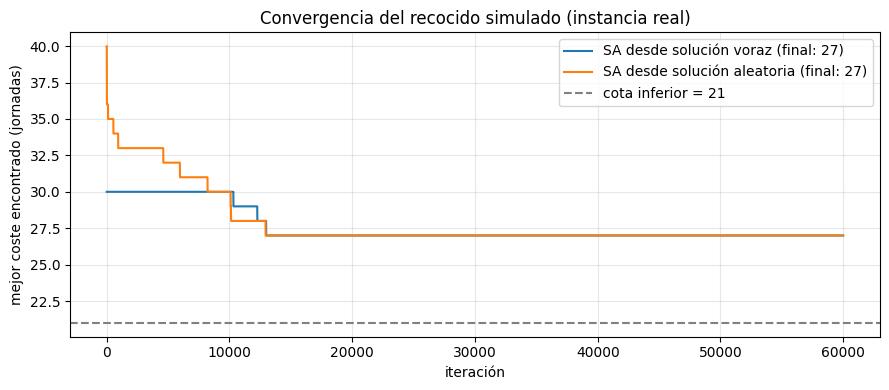

PLANIFICACIÓN FINAL (mejor solución del recocido simulado):
  Día 1: tomas [1, 5, 11, 22, 27, 30]  ->  actores [1, 2, 3, 4, 5, 8]  (coste: 6)
  Día 2: tomas [14, 17, 18, 19, 23, 24]  ->  actores [1, 3, 6]  (coste: 3)
  Día 3: tomas [2, 10, 12, 20, 26, 28]  ->  actores [1, 2, 3, 4, 5, 6, 9]  (coste: 7)
  Día 4: tomas [3, 4, 8, 15, 21, 29]  ->  actores [1, 2, 5, 6, 7, 8]  (coste: 6)
  Día 5: tomas [6, 7, 9, 13, 16, 25]  ->  actores [1, 2, 4, 5, 10]  (coste: 5)
  COSTE TOTAL: 27 jornadas de actor


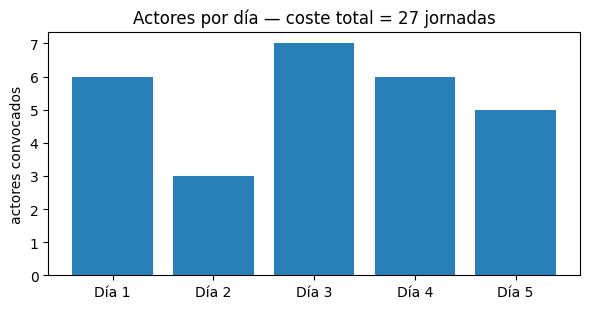


VALIDACIÓN en la instancia reducida (10 primeras tomas):
  Recocido con días de tamaños [5, 5]: 13 jornadas
  Recocido con días de tamaños [6, 4]: 13 jornadas
  Óptimo exacto (fuerza bruta)      : 13 jornadas
  -> la heurística ALCANZA el óptimo exacto


In [11]:
# =====================================================================
# RESULTADOS: CONVERGENCIA, PLANIFICACIÓN FINAL Y VALIDACIÓN
# =====================================================================

# --- Curva de convergencia del recocido simulado ----------------------
plt.figure(figsize=(9, 4))
plt.plot(sa1_hist, label=f"SA desde solución voraz (final: {sa1_c})")
plt.plot(sa2_hist, label=f"SA desde solución aleatoria (final: {sa2_c})")
plt.axhline(COTA, ls="--", c="gray", label=f"cota inferior = {COTA}")
plt.xlabel("iteración"); plt.ylabel("mejor coste encontrado (jornadas)")
plt.title("Convergencia del recocido simulado (instancia real)")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

# --- Planificación final legible --------------------------------------
def imprimir_planificacion(perm, matriz, limites_dias, mascaras):
    """Muestra, para cada día: tomas, actores convocados y coste del día."""
    total = 0
    for d, (i, j) in enumerate(limites_dias, 1):
        tomas = list(perm[i:j])
        actores = sorted(int(a) for a in np.where(matriz[tomas].any(axis=0))[0] + 1)
        c = coste_dia(tomas, mascaras)
        total += c
        print(f"  Día {d}: tomas {sorted(t + 1 for t in tomas)}"
              f"  ->  actores {actores}  (coste: {c})")
    print(f"  COSTE TOTAL: {total} jornadas de actor")
    return total

print("PLANIFICACIÓN FINAL (mejor solución del recocido simulado):")
imprimir_planificacion(SOLUCION_FINAL, MATRIZ, LIMITES, MASCARAS)

# --- Ilustración: actores convocados por día --------------------------
costes_por_dia = [coste_dia(SOLUCION_FINAL[i:j], MASCARAS) for (i, j) in LIMITES]
plt.figure(figsize=(6, 3.2))
plt.bar([f"Día {d}" for d in range(1, N_DIAS + 1)], costes_por_dia, color="#2980b9")
plt.ylabel("actores convocados")
plt.title(f"Actores por día — coste total = {COSTE_FINAL} jornadas")
plt.tight_layout(); plt.show()

# --- VALIDACIÓN: ¿alcanza la heurística el óptimo exacto? -------------
# En la instancia reducida (10 tomas) conocemos el óptimo por fuerza bruta.
print("\nVALIDACIÓN en la instancia reducida (10 primeras tomas):")
mejores = []
for tam_red in ([5, 5], [6, 4]):          # patrones de tamaños de día factibles
    lim_red = limites(tam_red)
    dpos_red = dia_de_cada_posicion(lim_red)
    _, c_red, _, _ = recocido_simulado(
        solucion_aleatoria(N_RED, rng), MASCARAS[:N_RED],
        lim_red, dpos_red, rng, max_iter=20000)
    mejores.append(c_red)
    print(f"  Recocido con días de tamaños {tam_red}: {c_red} jornadas")
print(f"  Óptimo exacto (fuerza bruta)      : {COSTE_OPT_RED} jornadas")
print("  -> la heurística ALCANZA el óptimo exacto"
      if min(mejores) == COSTE_OPT_RED else
      f"  -> gap respecto al óptimo: {min(mejores) - COSTE_OPT_RED}")

**(9)Calcula la complejidad del algoritmo**

#### Respuesta

Sea $n$ = tomas, $a$ = actores, $c$ = capacidad (6), $D=\lceil n/c\rceil$ días, $I$ = iteraciones (presupuesto).
Con $a\le 64$ actores, las operaciones de máscara (OR, *popcount*) cuestan $O(1)$ (una palabra de máquina); en general $O(\lceil a/64\rceil)$.

| Componente | Tiempo | Justificación |
|---|---|---|
| Constructivo voraz | $O(n^2)$ | por cada uno de los $n$ huecos se examinan $O(n)$ tomas pendientes con evaluación $O(1)$ |
| $\delta$ de un intercambio | $O(c)$ | solo se reevalúan los 2 días afectados (evaluación incremental) |
| Búsqueda local | $O(V\cdot c)$ | $V$ vecinos evaluados hasta el criterio de parada |
| **Recocido simulado** | $\boxed{O(I\cdot c)}$ | $I$ iteraciones × coste constante por iteración |
| Memoria | $O(n + n\cdot a)$ | permutación + costes por día + matriz/máscaras |

**Comparación con la fuerza bruta.** Pasamos de $O\bigl(n\cdot B_{\le 6}(n)\bigr)$ —ligado al **tamaño del espacio de soluciones**— a $O(I\cdot c)$, donde $I$ es un **presupuesto controlable fijado por el usuario** e independiente de la combinatoria del problema. Con los parámetros usados ($I=60.000$, $c = 6$) la instancia completa se resuelve en ~1–3 segundos frente a los ~$10^{12}$ años extrapolados para la fuerza bruta. El precio de esta mejora es la **pérdida de la garantía de optimalidad** (método aproximado y probabilista), mitigada con la validación frente al óptimo exacto de la instancia reducida y frente a la cota inferior.


**(10)De acuerdo al problema, diseña un juego de datos de entrada aleatorios**

#### Respuesta

Se diseña un **generador de instancias aleatorias** parametrizable que imita la estructura de la instancia real (donde 2 actores "protagonistas" concentran la mayoría de participaciones y el resto son secundarios):

- **Parámetros:** nº de tomas, número de actores, número de protagonistas, probabilidad de participación de protagonistas ($p\approx0{,}65$) y de secundarios ($p\approx0{,}18$), y **semilla** (reproducibilidad).
- **Garantías de validez:** toda toma tiene al menos 1 actor y todo actor aparece en al menos 1 toma (si el azar deja alguna fila/columna vacía, se corrige).
- El generador devuelve una matriz binaria *tomas × actores* con el **mismo formato** que la instancia real, por lo que **todo el código anterior se reutiliza sin cambios** (los algoritmos son genéricos).


Instancia aleatoria generada: 45 tomas x 12 actores
Participaciones por actor: [31 26  7  7 13  8  8 10 11  4  8  3]


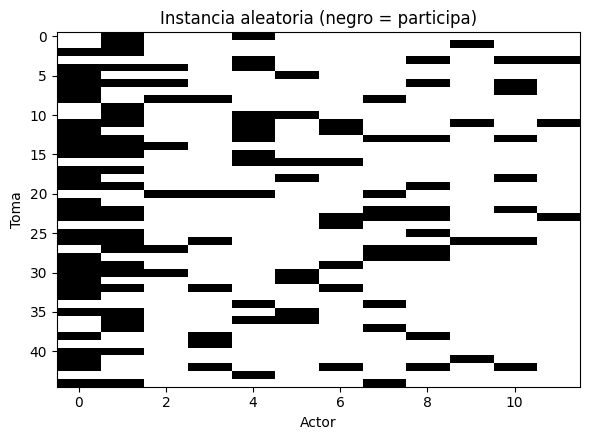

In [13]:
# =====================================================================
# GENERADOR DE INSTANCIAS ALEATORIAS
# =====================================================================
def generar_instancia(n_tomas, n_actores, semilla,
                      n_protagonistas=2, p_protagonista=0.65, p_secundario=0.18):
    """Matriz binaria aleatoria (tomas x actores) con estructura realista:
    - los primeros 'n_protagonistas' actores aparecen con prob. alta;
    - el resto, con prob. baja;
    - se garantiza que toda toma tiene >= 1 actor y todo actor >= 1 toma."""
    gen = np.random.default_rng(semilla)
    p = np.full(n_actores, p_secundario)
    p[:n_protagonistas] = p_protagonista
    M = (gen.random((n_tomas, n_actores)) < p).astype(int)
    for i in range(n_tomas):                     # ninguna toma sin actores
        if M[i].sum() == 0:
            M[i, gen.integers(n_actores)] = 1
    for j in range(n_actores):                   # ningún actor sin tomas
        if M[:, j].sum() == 0:
            M[gen.integers(n_tomas), j] = 1
    return M

# --- Instancia aleatoria de mayor tamaño que la real ------------------
N_TOMAS_R, N_ACTORES_R = 45, 12
MATRIZ_R = generar_instancia(N_TOMAS_R, N_ACTORES_R, semilla=123)

print(f"Instancia aleatoria generada: {N_TOMAS_R} tomas x {N_ACTORES_R} actores")
print(f"Participaciones por actor: {MATRIZ_R.sum(axis=0)}")
plt.figure(figsize=(6, 4.5))
plt.imshow(MATRIZ_R, cmap="Greys", aspect="auto")
plt.xlabel("Actor"); plt.ylabel("Toma")
plt.title("Instancia aleatoria (negro = participa)")
plt.tight_layout(); plt.show()

**(11)Aplica el algoritmo al juego de datos generado**

#### Respuesta

Se aplica el **mismo pipeline** (voraz → recocido simulado) a la instancia aleatoria. Nótese que ahora $45$ tomas no es múltiplo de la capacidad: el modelo genera automáticamente $\lceil 45/6\rceil = 8$ días con tamaños equilibrados $\le 6$, y todos los algoritmos funcionan sin modificación alguna — evidencia de que la estructura de datos elegida generaliza bien.


Días: 8 con tamaños [6, 6, 6, 6, 6, 5, 5, 5]

Coste del constructivo voraz : 51 jornadas
Coste tras recocido simulado : 42 jornadas   (tiempo total: 1.00 s)
Cota inferior del óptimo     : 30 jornadas

PLANIFICACIÓN FINAL (instancia aleatoria):
  Día 1: tomas [4, 12, 13, 14, 24, 42]  ->  actores [1, 2, 5, 7, 8, 9, 10, 11, 12]  (coste: 9)
  Día 2: tomas [5, 11, 15, 16, 31, 36]  ->  actores [1, 2, 3, 5, 6]  (coste: 5)
  Día 3: tomas [7, 23, 26, 28, 38, 45]  ->  actores [1, 2, 3, 8, 9, 11]  (coste: 6)
  Día 4: tomas [2, 20, 27, 30, 33, 43]  ->  actores [1, 2, 4, 7, 9, 10, 11]  (coste: 7)
  Día 5: tomas [9, 21, 29, 35, 39, 40]  ->  actores [1, 3, 4, 5, 8, 9]  (coste: 6)
  Día 6: tomas [1, 17, 25, 37, 44]  ->  actores [2, 5, 6, 7]  (coste: 4)
  Día 7: tomas [6, 8, 19, 32, 34]  ->  actores [1, 6, 11]  (coste: 3)
  Día 8: tomas [3, 10, 18, 22, 41]  ->  actores [1, 2]  (coste: 2)
  COSTE TOTAL: 42 jornadas de actor


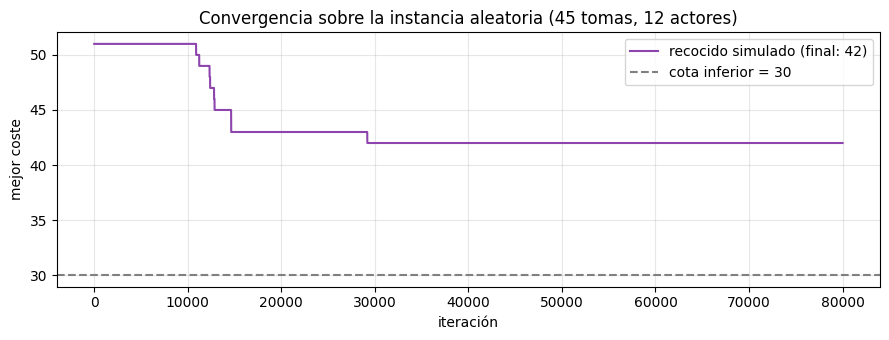

In [14]:
# =====================================================================
# APLICACIÓN DEL ALGORITMO A LA INSTANCIA ALEATORIA
# =====================================================================
# 1) Estructuras del modelo para la nueva instancia
MASCARAS_R   = construir_mascaras(MATRIZ_R)
TAMANOS_R    = tamanos_dias(N_TOMAS_R, CAPACIDAD)     # días equilibrados <= 6
LIMITES_R    = limites(TAMANOS_R)
DIA_DE_POS_R = dia_de_cada_posicion(LIMITES_R)
COTA_R       = cota_inferior(MATRIZ_R, CAPACIDAD)
print(f"Días: {len(TAMANOS_R)} con tamaños {TAMANOS_R}")

rng_r = random.Random(SEMILLA)

# 2) Solución inicial voraz + recocido simulado
t0 = time.perf_counter()
voraz_r  = solucion_voraz(MASCARAS_R, TAMANOS_R, rng_r)
c_voraz_r = coste_perm(voraz_r, MASCARAS_R, LIMITES_R)
sol_r, c_r, hist_r, _ = recocido_simulado(
    voraz_r, MASCARAS_R, LIMITES_R, DIA_DE_POS_R, rng_r, max_iter=80000)
t_total = time.perf_counter() - t0
verificar_solucion(sol_r, N_TOMAS_R, TAMANOS_R, CAPACIDAD)

print(f"\nCoste del constructivo voraz : {c_voraz_r} jornadas")
print(f"Coste tras recocido simulado : {c_r} jornadas   (tiempo total: {t_total:.2f} s)")
print(f"Cota inferior del óptimo     : {COTA_R} jornadas\n")

print("PLANIFICACIÓN FINAL (instancia aleatoria):")
imprimir_planificacion(sol_r, MATRIZ_R, LIMITES_R, MASCARAS_R)

# 3) Convergencia
plt.figure(figsize=(9, 3.5))
plt.plot(hist_r, color="#8e44ad", label=f"recocido simulado (final: {c_r})")
plt.axhline(COTA_R, ls="--", c="gray", label=f"cota inferior = {COTA_R}")
plt.xlabel("iteración"); plt.ylabel("mejor coste")
plt.title("Convergencia sobre la instancia aleatoria (45 tomas, 12 actores)")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

**(12)Enumera las referencias utilizadas**

#### Respuesta

1. Material de la asignatura: *VC5 – Algoritmos Heurísticos*, 03MIAR — Algoritmos de Optimización, Universidad Internacional de Valencia (VIU). (Búsqueda aleatoria, búsqueda local, multiarranque, GRASP y recocido simulado.)
2. Kirkpatrick, S.; Gelatt, C. D.; Vecchi, M. P. (1983). *Optimization by Simulated Annealing*. Science, 220(4598), 671–680.
3. Feo, T. A.; Resende, M. G. C. (1995). *Greedy Randomized Adaptive Search Procedures*. Journal of Global Optimization, 6, 109–133.
4. Luke, S. (2013). *Essentials of Metaheuristics* (2.ª ed.). Lulu. Disponible en: http://cs.gmu.edu/~sean/book/metaheuristics/
5. Duarte, A. (2008). *Metaheurísticas*. Madrid: Dykinson.
6. Documentación oficial de NumPy (https://numpy.org/doc/) y Matplotlib (https://matplotlib.org/stable/).

**Declaración de uso de IA.** Se ha utilizado el asistente de IA **Chat GPT** principalmente como apoyo en la implementación del código en evaluación incremental de la función objetivo con máscaras de bits, recocido simulado con calibración automática de la temperatura inicial y enumerador de particiones de la fuerza bruta.r.


**(13)Describe brevemente las lineas de como crees que es posible avanzar en el estudio del problema. Ten en cuenta incluso posibles variaciones del problema y/o variaciones al alza del tamaño.**

#### Respuesta

**Variaciones del problema (hacia un modelo más realista):**
- Número de días **variable** con un coste fijo por abrir jornada de estudio (el óptimo dejaría de estar necesariamente en el mínimo de días).
- **Tarifas distintas por actor** (la función objetivo pasa a ser una suma ponderada) y **calendarios de disponibilidad** (restricciones duras adicionales).
- Tomas con **duración**: la capacidad diaria pasa de 6 tomas a X minutos, convirtiendo el problema en un *bin packing* con costes de unión de conjuntos.

**Variaciones al alza del tamaño (p. ej. 300 tomas y 50 actores):**
- **Vecindarios más ricos**: mover una toma entre días con hueco, cadenas de intercambios (*ejection chains*) y vecindarios variables (VNS).
- **Búsqueda tabú** sobre los movimientos recientes para evitar ciclados en mesetas de la función objetivo (frecuentes en este problema: muchos intercambios tienen $\delta = 0$).
- Métodos **poblacionales**: algoritmos genéticos/meméticos con cruces que preserven grupos de tomas, o **colonia de hormigas** con feromona sobre pares de tomas que conviene grabar juntas.
- **Hibridación** (multiarranque GRASP + recocido), ajuste automático de parámetros ($\alpha$, $T_0$, presupuesto) y paralelización de arranques independientes.
- **Cotas más finas** para certificar la calidad sin solver (relajaciones lineales del modelo de cobertura, cotas por subconjuntos de actores coocurrentes) o, como permite el enunciado, un solver exacto usado **únicamente** como referencia de distancia al óptimo.
